# Breast Cancer Classification: Model Comparison and Diagnostic Metrics

Comparing supervised learning models with emphasis on sensitivity, specificity, ROC-AUC, and classification-threshold trade-offs.

We work with the Breast Cancer Wisconsin (Diagnostic) Data Set. Ten features are computed from a digitized image of a fine needle aspirate of a breast mass. They describe characteristics of the cell nuclei present in the image. The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features.

The data is labeled for Benign and Malignant tumors. 

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Train/test split and cross-validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    cross_val_predict,
    GridSearchCV
)

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    make_scorer, 
    recall_score
)
from sklearn.inspection import permutation_importance

from sklearn.ensemble import StackingClassifier, VotingClassifier

# Make nicer-looking plots (font sizes and other parameters)
import plot_utils  

## Load and inspect the data
Note that the dataset is quite imbalanced

In [2]:
# Load the Wisconsin Diagnostic Breast Cancer dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target
df["target"] = data.target

# sklearn encodes the target as: 0 = malignant, 1 = benign
# For clearer interpretation of the forthcoming sensitivity/specificity analysis, 
# we redefine the target so that malignant = 1 and benign = 0:
df["target"] = (df["target"] == 0).astype(int)
print(f"Class distribution:")
vc = df["target"].value_counts()
print(f"  Benign (0)    : {vc[0]}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Malignant (1) : {vc[1]}  ({vc[1]/len(df)*100:.1f}%)")

df.head()

Class distribution:
  Benign (0)    : 357  (62.7%)
  Malignant (1) : 212  (37.3%)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
# The dataset has the mean, error, and "worst" of the 10 features measured
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

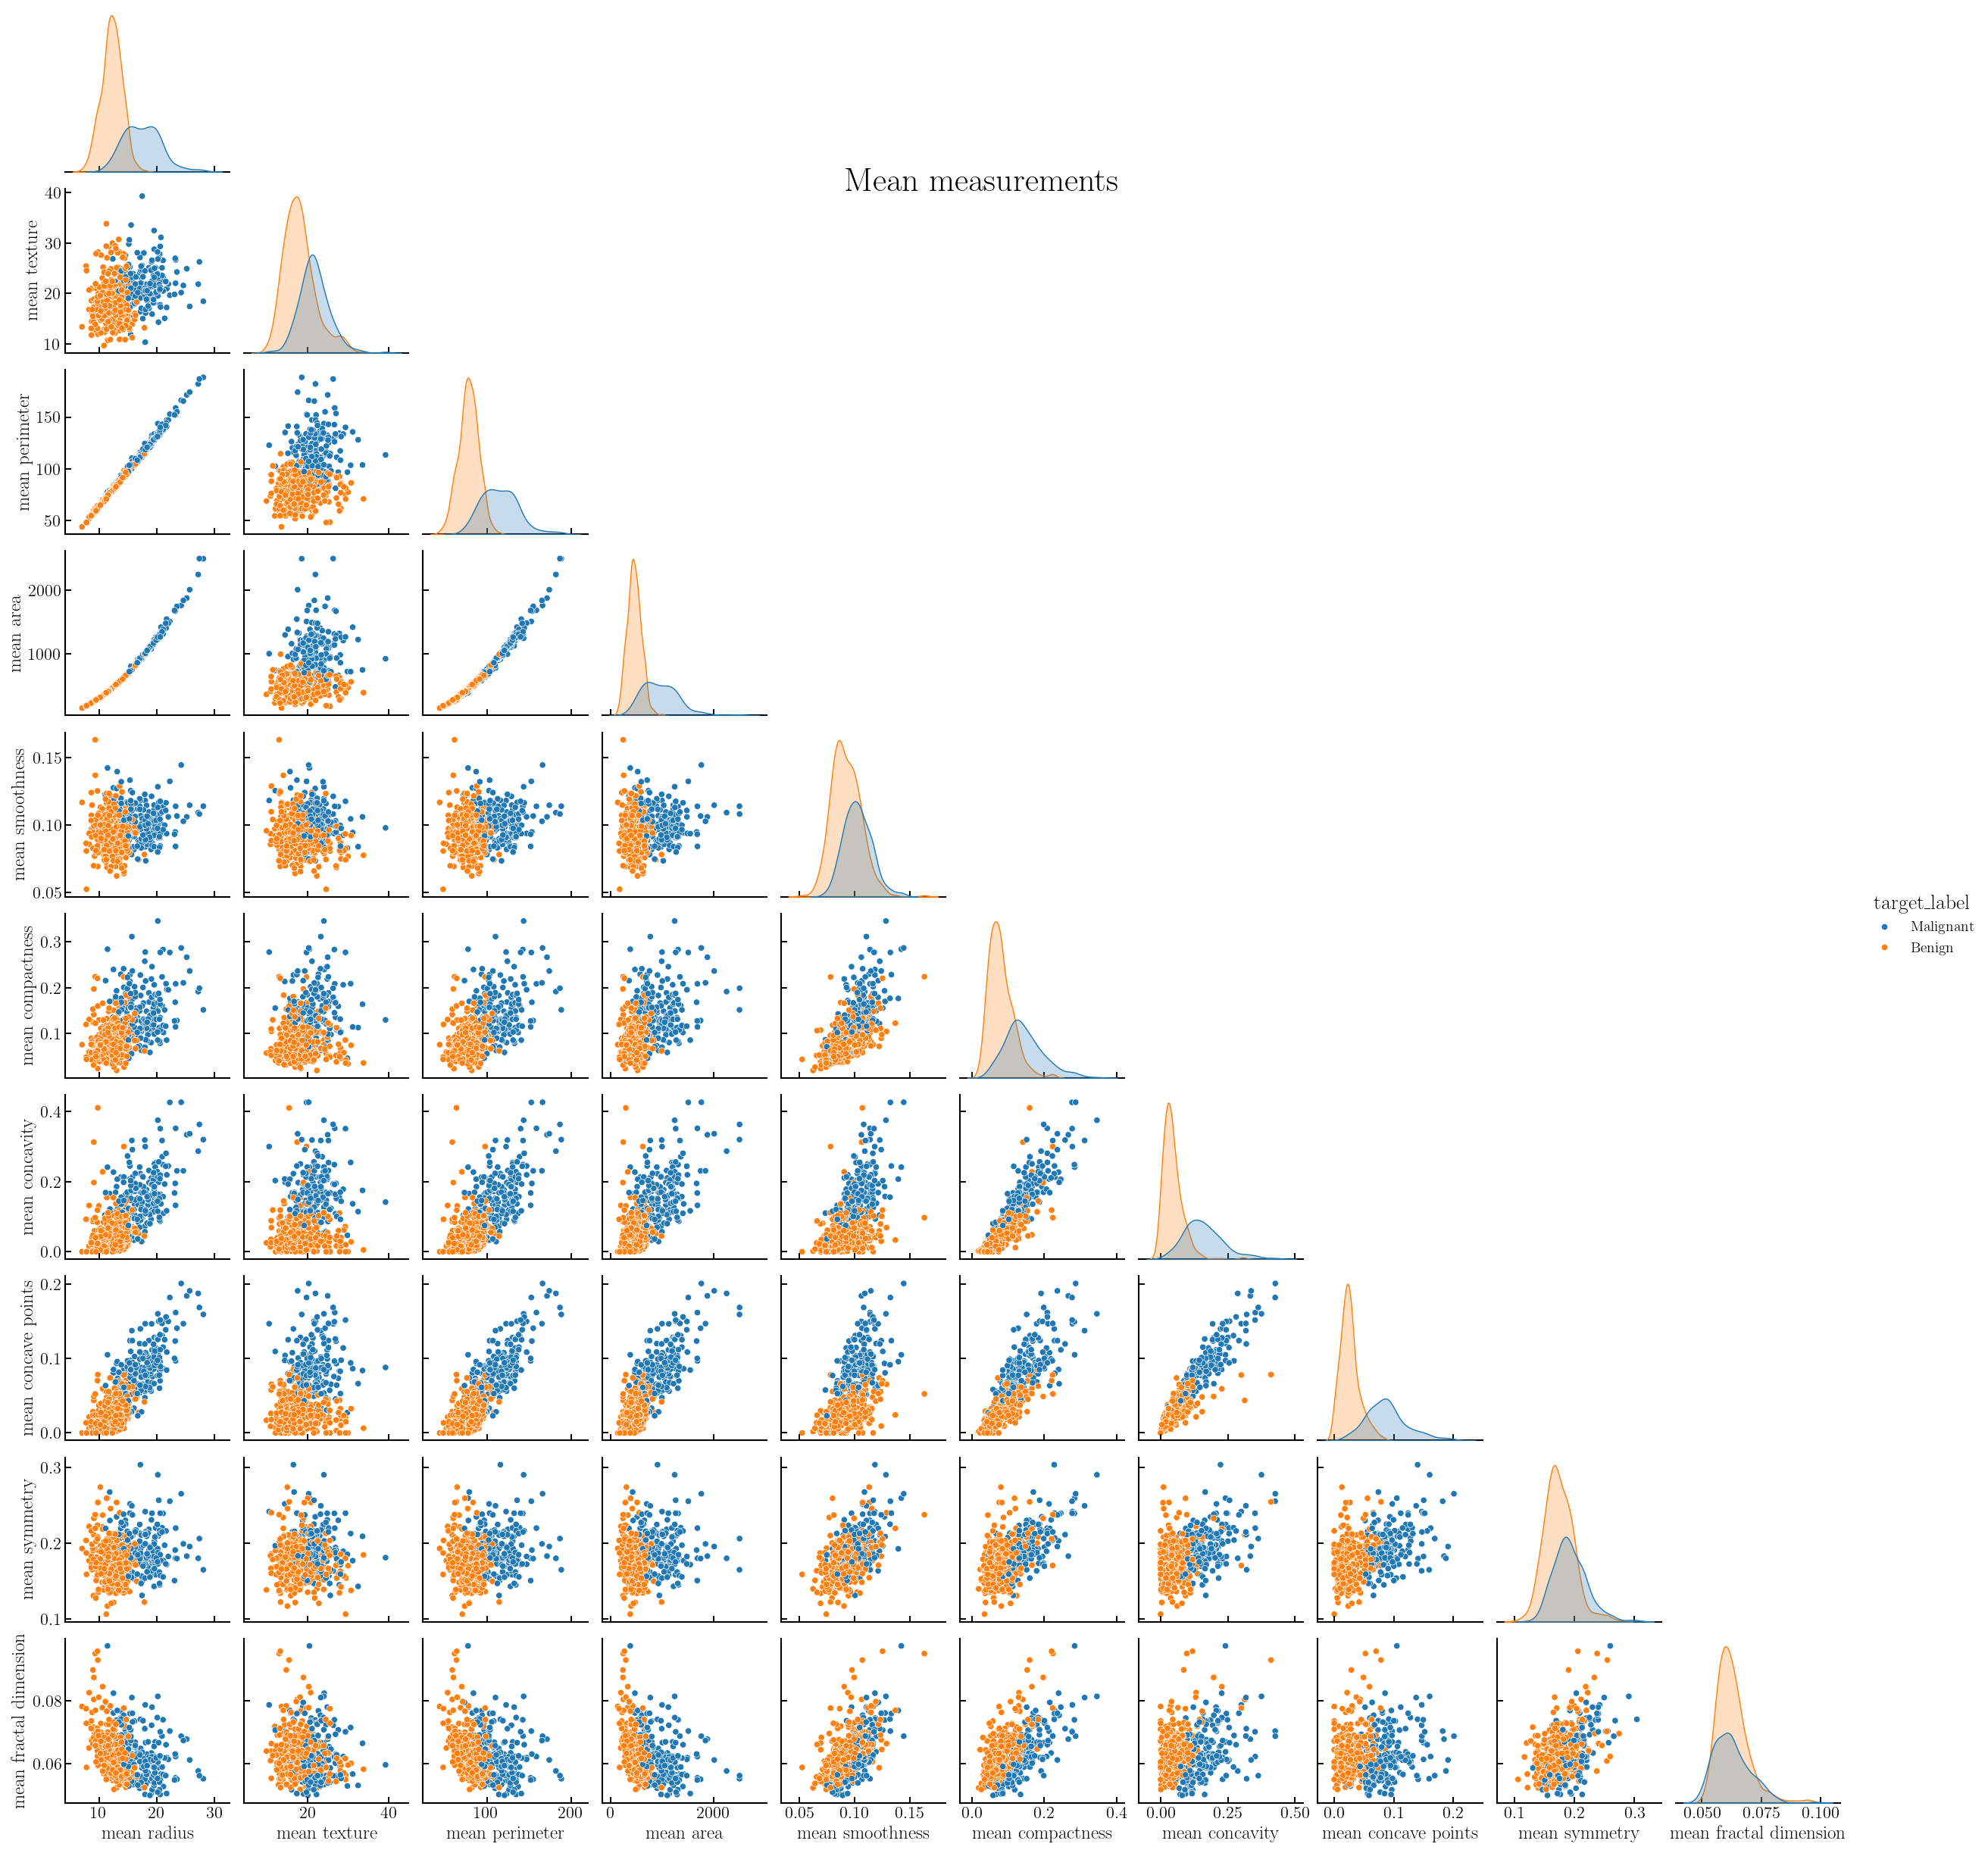

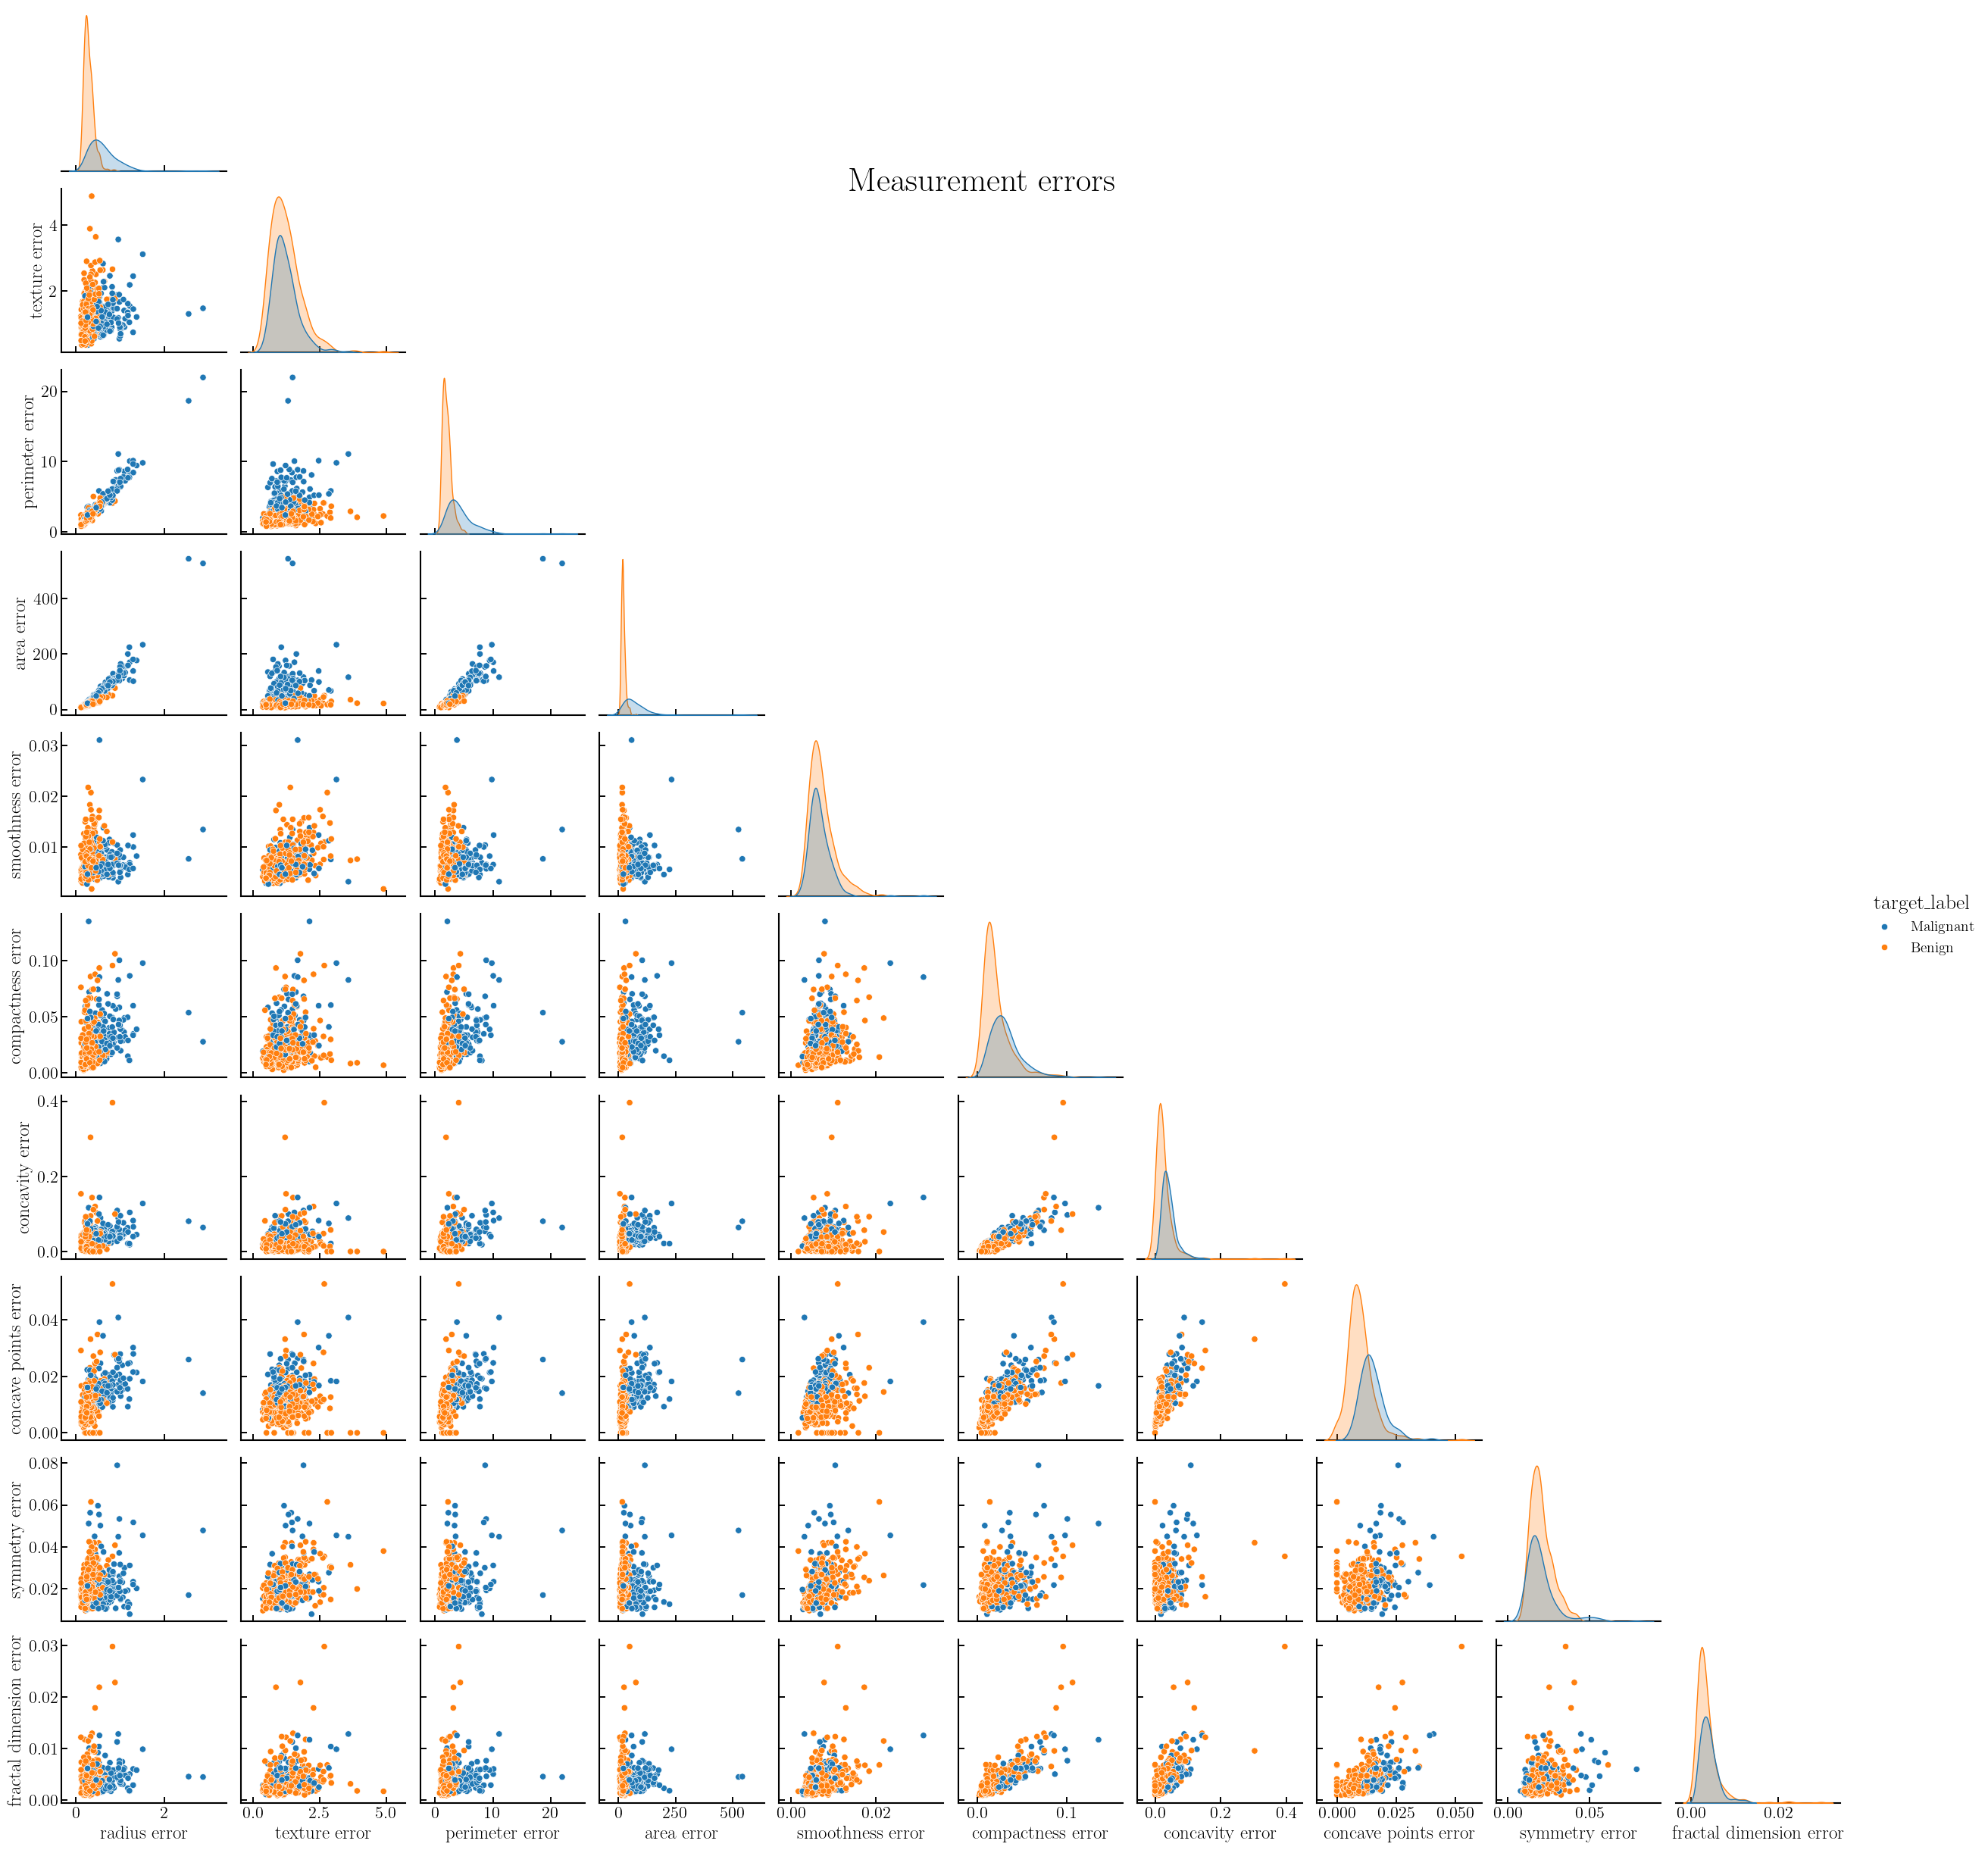

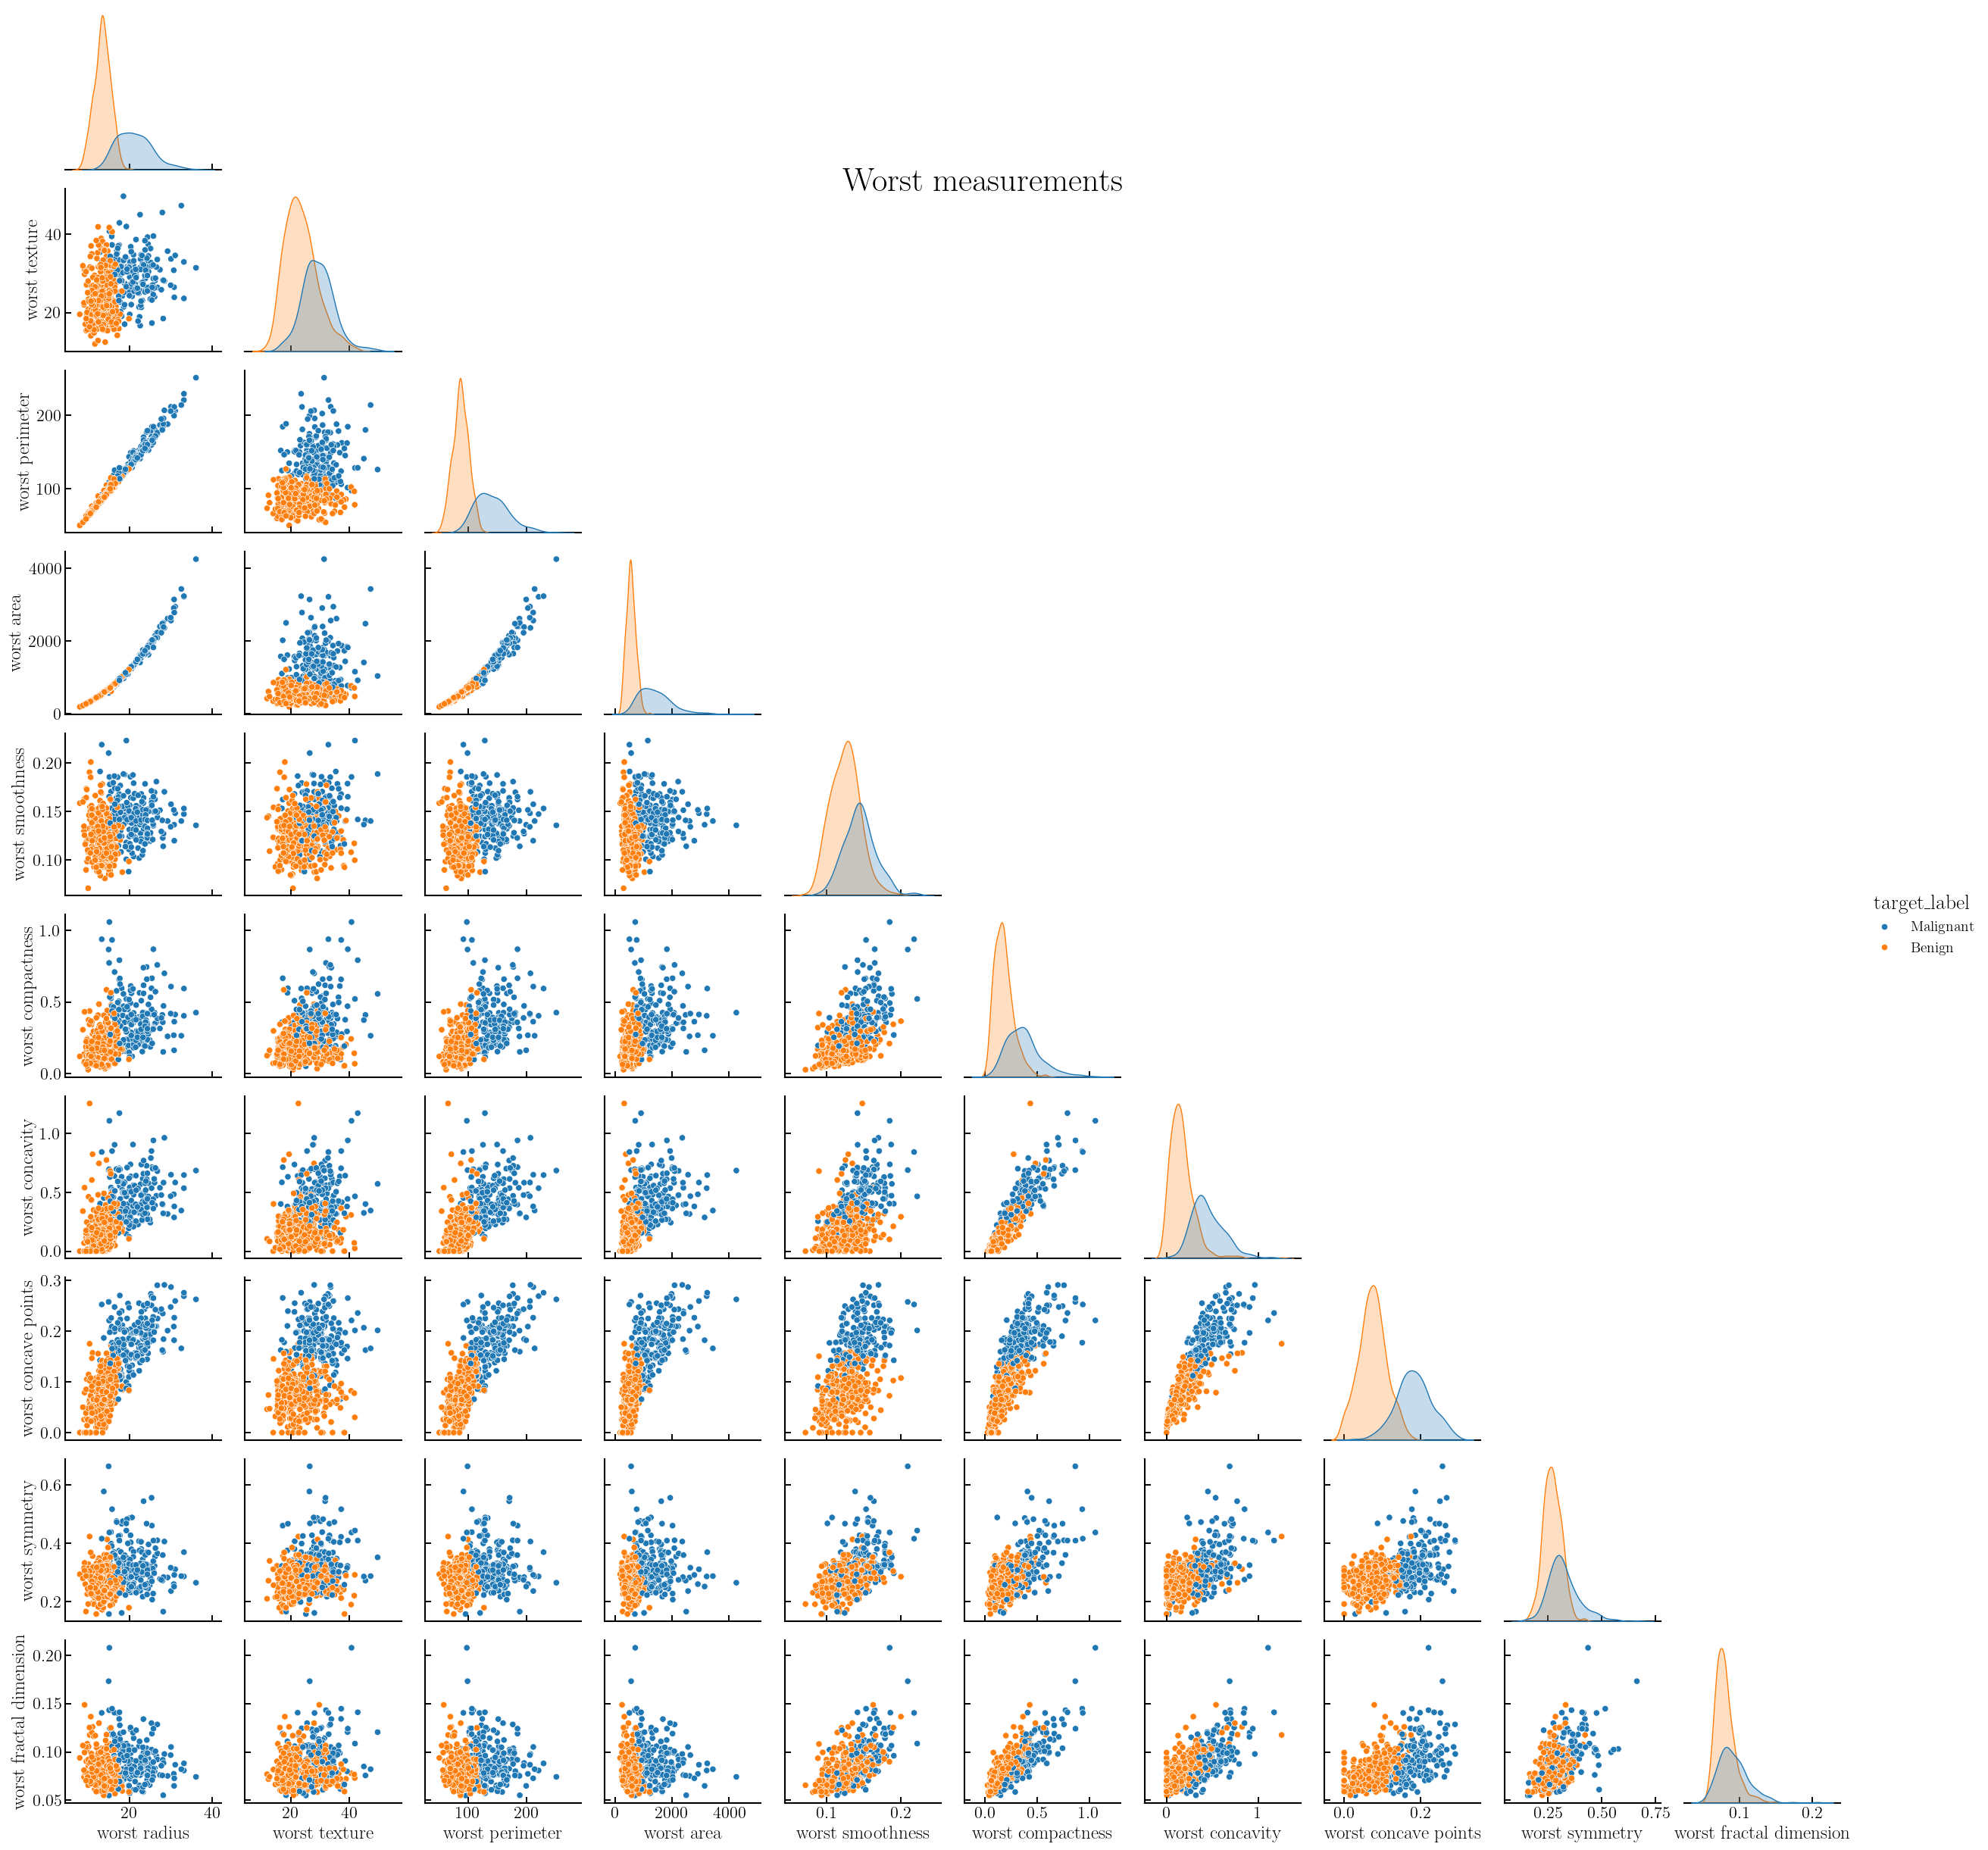

In [4]:
# We split the 30 features in 3 groups for plotting
features = df.drop(columns="target").columns

# Make an auxiliary column to have more informative legends
df['target_label'] = df['target'].map({0: 'Benign', 1: 'Malignant'})

g1=sns.pairplot(
    data=df,
    vars=features[:10],
    corner=True,
    hue="target_label"
)
g1.fig.suptitle("Mean measurements", y=0.9, size=32) 


g2=sns.pairplot(
    data=df,
    vars=features[10:20],
    corner=True,
    hue="target_label"
)
g2.fig.suptitle("Measurement errors", y=0.9, size=32) 


g3=sns.pairplot(
    data=df,
    vars=features[20:30],
    corner=True,
    hue="target_label"
)
g3.fig.suptitle("Worst measurements", y=0.9, size=32) 


# Drop the auxiliary column
df.drop('target_label', axis=1, inplace=True)

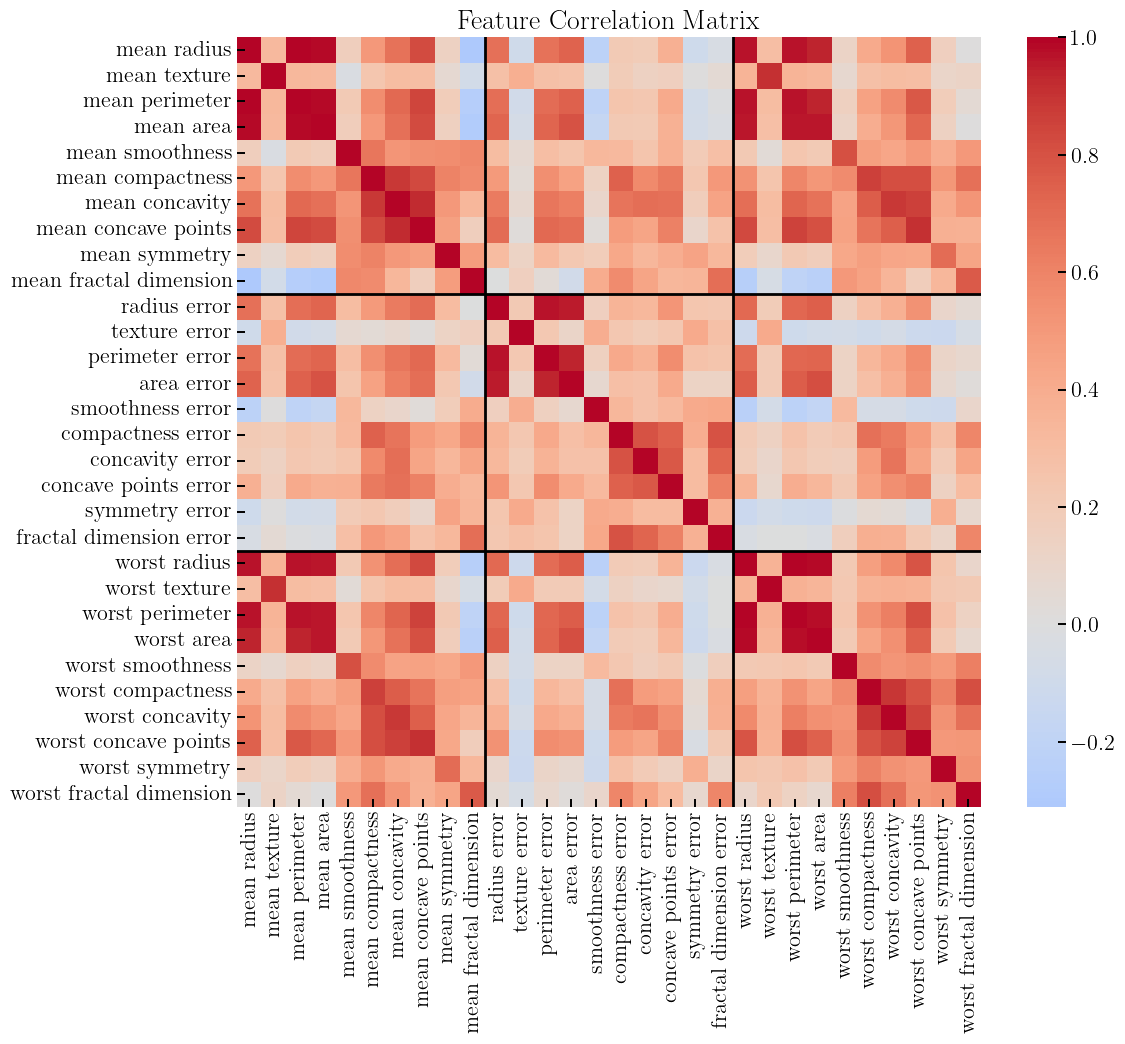

In [5]:
corr = df.drop(columns="target").corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)

# Add black lines at positions 10 and 20
for pos in [10, 20]:
    ax.axvline(x=pos, color='black', linewidth=2)
    ax.axhline(y=pos, color='black', linewidth=2)

plt.title("Feature Correlation Matrix")
plt.show()

### Control: check if parameters have mean values of zero
The only potentially problematic parameter is the concativity, but in that case also its error and worst are zero, so we will still be able to work with the ratios in sensible ways

In [6]:
df.loc[
    df["mean concavity"] == 0,
    ["mean concavity", "concavity error", "worst concavity"]
]

,mean concavity,concavity error,worst concavity
101,0.0,0.0,0.0
140,0.0,0.0,0.0
174,0.0,0.0,0.0
175,0.0,0.0,0.0
192,0.0,0.0,0.0
314,0.0,0.0,0.0
391,0.0,0.0,0.0
473,0.0,0.0,0.0
538,0.0,0.0,0.0
550,0.0,0.0,0.0


## Explore which features are most informative for the classification models

We build different combinations of features (mean, erros, worst).

In [7]:
quantities = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave points",
    "symmetry",
    "fractal dimension",
]

mean_features = [f"mean {q}" for q in quantities]
error_features = [f"{q} error" for q in quantities]
worst_features = [f"worst {q}" for q in quantities]
ratio_features = [f"{q} worst/mean" for q in quantities]

# 1. Mean
X_mean = df[mean_features].copy()
y_mean = df["target"].copy()

# 2. Mean + errors
X_mean_errors = df[mean_features + error_features].copy()
y_mean_errors = df["target"].copy()

# 3. Mean + worst
X_mean_worst = df[mean_features + worst_features].copy()
y_mean_worst = df["target"].copy()

# 4. Mean + errors + worst
X_mean_errors_worst = df[mean_features + error_features + worst_features].copy()
y_mean_errors_worst = df["target"].copy()

# 5. Mean + relative worst
X_mean_worst_rel = df[mean_features].copy()
for q in quantities:
    X_mean_worst_rel[f"{q} worst/mean"] = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"worst {q}"] / df[f"mean {q}"])
y_mean_worst_rel = df["target"].copy()

# 6. Mean + relative errors + relative worst
X_mean_rel = df[mean_features].copy()
for q in quantities:
    X_mean_rel[f"{q} error/mean"] = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"{q} error"] / df[f"mean {q}"])
    X_mean_rel[f"{q} worst/mean"] = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"worst {q}"] / df[f"mean {q}"])
y_mean_rel = df["target"].copy()

In [8]:
# We do the cross validation with a training set

X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(
    X_mean, y_mean, test_size=0.2, stratify=y_mean, random_state=42)

X_train_mean_errors, X_test_mean_errors, y_train_mean_errors, y_test_mean_errors = train_test_split(
    X_mean_errors, y_mean_errors, test_size=0.2, stratify=y_mean_errors, random_state=42)

X_train_mean_errors_worst, X_test_mean_errors_worst, y_train_mean_errors_worst, y_test_mean_errors_worst = train_test_split(
    X_mean_errors_worst, y_mean_errors_worst, test_size=0.2, stratify=y_mean_errors_worst, random_state=42)

X_train_mean_worst_rel, X_test_mean_worst_rel, y_train_mean_worst_rel, y_test_mean_worst_rel = train_test_split(
    X_mean_worst_rel, y_mean_worst_rel, test_size=0.2, stratify=y_mean_worst_rel, random_state=42)

X_train_mean_rel, X_test_mean_rel, y_train_mean_rel, y_test_mean_rel = train_test_split(
    X_mean_rel, y_mean_rel, test_size=0.2, stratify=y_mean_rel, random_state=42)

X_train_mean_worst, X_test_mean_worst, y_train_mean_worst, y_test_mean_worst = train_test_split(
    X_mean_worst, y_mean_worst, test_size=0.2, stratify=y_mean_worst, random_state=42)

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_rf(X, y):
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "recall": "recall",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    return {
        metric: (
            scores[f"test_{metric}"].mean(),
            scores[f"test_{metric}"].std()
        )
        for metric in ["accuracy", "recall", "roc_auc"]
    }

results = {
    "Mean": evaluate_rf(X_train_mean, y_train_mean),
    "Mean + error": evaluate_rf(X_train_mean_errors, y_train_mean_errors),
    "Mean + worst": evaluate_rf(X_train_mean_worst, y_train_mean_worst),
    "Mean + error + worst": evaluate_rf(X_train_mean_errors_worst, y_train_mean_errors_worst),
    "Mean + relative worst": evaluate_rf(X_train_mean_worst_rel, y_train_mean_worst_rel),
    "Mean + relative error + relative worst": evaluate_rf(X_train_mean_rel, y_train_mean_rel),
}
for dataset, metrics in results.items():
    print(f"\n{dataset}")
    
    for metric, (mean, std) in metrics.items():
        print(f"  {metric:8s}: {mean:.3f} ± {std:.3f}")


Mean
  accuracy: 0.943 ± 0.019
  recall  : 0.912 ± 0.053
  roc_auc : 0.984 ± 0.008

Mean + error
  accuracy: 0.949 ± 0.018
  recall  : 0.918 ± 0.051
  roc_auc : 0.985 ± 0.009

Mean + worst
  accuracy: 0.965 ± 0.020
  recall  : 0.941 ± 0.042
  roc_auc : 0.987 ± 0.010

Mean + error + worst
  accuracy: 0.960 ± 0.016
  recall  : 0.935 ± 0.039
  roc_auc : 0.988 ± 0.007

Mean + relative worst
  accuracy: 0.976 ± 0.016
  recall  : 0.953 ± 0.030
  roc_auc : 0.989 ± 0.010

Mean + relative error + relative worst
  accuracy: 0.974 ± 0.018
  recall  : 0.947 ± 0.034
  roc_auc : 0.989 ± 0.011


# Explore different ML models for the best feature combination
The exploratory analysis revealed that combining mean with relative worst gives the best results.
When mean and worst = 0, we set the ratio worst/mean to zero. 

In [10]:
X = df[mean_features].copy()

for q in quantities:
    ratio = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"worst {q}"] / df[f"mean {q}"]
    )

    X[f"{q} worst/mean"] = ratio

y = df["target"].copy()

## Baseline model

Note that we use only the training data for cross validation

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
logistic_pipeline = Pipeline([
    ("preprocessor", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])


svm_pipeline = Pipeline([
    ("preprocessor", StandardScaler()),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])


rf_pipeline = Pipeline([
    ("preprocessor", "passthrough"),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])


gb_pipeline = Pipeline([
    ("preprocessor", "passthrough"),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])


knn_pipeline = Pipeline([
    ("preprocessor", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "specificity": specificity_scorer,
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "K-Nearest Neighbors": knn_pipeline
}

results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        metric: (
            scores[f"test_{metric}"].mean(),
            scores[f"test_{metric}"].std()
        )
        for metric in scoring
    }

In [14]:
results_df = pd.DataFrame(
    {
        model: {
            metric: f"{mean * 100:.1f} ± {std * 100:.1f}%"
            for metric, (mean, std) in metrics.items()
        }
        for model, metrics in results.items()
    }
).T

results_df.index.name = "Model"

results_df

,accuracy,recall,specificity,roc_auc
Model,,,,
Logistic Regression,97.4 ± 0.9%,95.3 ± 3.0%,98.6 ± 1.3%,99.2 ± 0.7%
SVM,97.4 ± 1.6%,93.5 ± 5.1%,99.6 ± 0.7%,99.4 ± 0.8%
Random Forest,97.6 ± 1.6%,95.3 ± 3.0%,98.9 ± 0.9%,98.9 ± 1.0%
Gradient Boosting,97.1 ± 1.1%,94.7 ± 2.2%,98.6 ± 1.7%,99.0 ± 1.1%
K-Nearest Neighbors,95.4 ± 3.0%,88.2 ± 7.4%,99.6 ± 0.7%,97.4 ± 1.7%


## Hyperparameter tuning

Hyperparameters are selected using stratified cross-validation on the training split only. The test split remains untouched until the final evaluation.

Nested cross-validation would provide a less optimistic estimate of model-selection performance; it is outside the scope of this project.

We use ROC_AUC as a scorer for optimization, as we later search for the best threshold.

In [15]:
# I made a denser grid after some broad sampling
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 0.3, 1, 1.5, 2, 3]
    },

    "SVM": {
        "classifier__C": [0.1, 1, 2, 4, 8],
        "classifier__gamma": ["scale", 0.01, 0.03, 0.1, 0.3, 1]
    },

    "Random Forest": {
        "classifier__n_estimators": [150, 180, 200],
        "classifier__max_depth": [None, 5, 8, 10, 12],
        "classifier__min_samples_leaf": [1, 2, 5]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [100, 130, 200],
        "classifier__learning_rate": [0.05, 0.1, 0.15, 0.2],
        "classifier__max_depth": [1, 2, 3]
    },

    "K-Nearest Neighbors": {    
        "classifier__n_neighbors": [3, 5, 7, 9, 11],
        "classifier__weights": ['uniform', 'distance'],
        "classifier__metric": ['euclidean', 'manhattan']
    }
}

In [16]:
models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "K-Nearest Neighbors": knn_pipeline
}

In [17]:
tuned_models = {}
tuning_results = {}

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    tuned_models[name] = grid.best_estimator_

    tuning_results[name] = {
        "best_params": grid.best_params_,
        "best_roc_auc": grid.best_score_
    }

    print(f"\n{name}")
    print(f"  Best parameters: {grid.best_params_}")
    print(f"  Best ROC-AUC:    {grid.best_score_:.3f}")


Logistic Regression
  Best parameters: {'classifier__C': 1.5}
  Best ROC-AUC:    0.992

SVM
  Best parameters: {'classifier__C': 2, 'classifier__gamma': 0.03}
  Best ROC-AUC:    0.995

Random Forest
  Best parameters: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 180}
  Best ROC-AUC:    0.991

Gradient Boosting
  Best parameters: {'classifier__learning_rate': 0.15, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
  Best ROC-AUC:    0.995

K-Nearest Neighbors
  Best parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
  Best ROC-AUC:    0.989


In [18]:
# Evaluate tuned models on the training split for model comparison
# These cross-validated values support model selection; they are not the final test estimate.
results_tuned_cv = {}

for name, model in tuned_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results_tuned_cv[name] = {
        metric: (
            scores[f"test_{metric}"].mean(),
            scores[f"test_{metric}"].std()
        )
        for metric in scoring
    }

In [19]:
results_tuned_cv_df = pd.DataFrame(
    {
        model: {
            metric: f"{mean * 100:.1f} ± {std * 100:.1f}%"
            for metric, (mean, std) in metrics.items()
        }
        for model, metrics in results_tuned_cv.items()
    }
).T

results_tuned_cv_df.index.name = "Model"
results_tuned_cv_df

,accuracy,recall,specificity,roc_auc
Model,,,,
Logistic Regression,97.4 ± 0.9%,95.3 ± 3.0%,98.6 ± 1.3%,99.2 ± 0.7%
SVM,98.0 ± 1.3%,95.3 ± 4.0%,99.6 ± 0.7%,99.5 ± 0.7%
Random Forest,97.8 ± 1.6%,95.3 ± 3.0%,99.3 ± 0.9%,99.1 ± 0.7%
Gradient Boosting,98.0 ± 1.3%,95.9 ± 3.0%,99.3 ± 1.4%,99.5 ± 0.6%
K-Nearest Neighbors,96.0 ± 2.4%,89.4 ± 6.3%,100.0 ± 0.0%,98.9 ± 0.8%


# Final model selection and test evaluation

We test two different ensembles: voting with weights and stacking.

The tuned models and ensembles are now evaluated once on the untouched test split. No test-set metric is used for model selection.

In [20]:
# Build the ensemble models using the tuned estimators.
# Their training-split cross-validation scores are diagnostic only.

# For the weights we use the roc_auc score of the model, but they 
# are all very similar, so we sustract some baseline first
cv_scores_ensemble = [
    tuning_results[name]["best_roc_auc"]
    for name in models.keys()
]
roc_auc_scores = np.asarray(cv_scores_ensemble)
baseline_fraction = 0.99
raw_weights = roc_auc_scores - baseline_fraction * roc_auc_scores.min()
weights = raw_weights / raw_weights.sum()

voting_clf = VotingClassifier(
    estimators=list(tuned_models.items()),
    voting="soft",
    weights=weights
)

stacking_clf = StackingClassifier(
    estimators=list(tuned_models.items())
)

ensemble_voting = cross_val_score(
    voting_clf,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

ensemble_stacking = cross_val_score(
    stacking_clf,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

print(f"Voting ensemble training-CV roc_auc: {ensemble_voting.mean():.3f} ± {ensemble_voting.std():.3f}")
print(f"Stacking ensemble training-CV roc_auc: {ensemble_stacking.mean():.3f} ± {ensemble_stacking.std():.3f}")

Voting ensemble training-CV roc_auc: 0.994 ± 0.007
Stacking ensemble training-CV roc_auc: 0.994 ± 0.007


In [21]:
# Fit every selected model on the complete training split and evaluate once on the test split.
final_models = {
    **tuned_models,
    "Voting": voting_clf,
    "Stacking": stacking_clf,
}

# We do a final fit of all tuned models
for model in final_models.values():
    model.fit(X_train, y_train)

## Threshold selection
We will select a threshold to ensure that we do not miss positive but do not do too bad in specificity (at least a 90%)

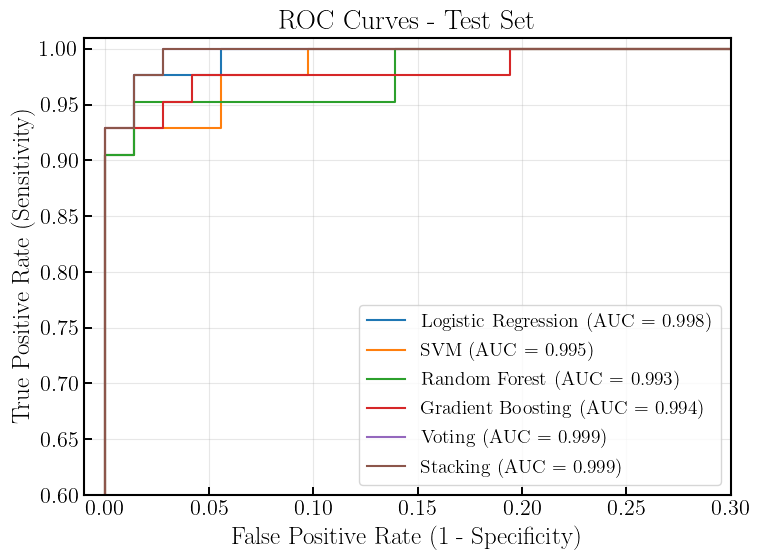

In [22]:
# ROC curves on the untouched test split.
models_for_roc = {
    name: model
    for name, model in final_models.items()
    if name != "K-Nearest Neighbors"
}

plt.figure(figsize=(8, 6))

for name, model in models_for_roc.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.xlim(-0.01, 0.3)
plt.ylim(0.6, 1.01)
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves - Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/roc_curves.png", dpi=200)
plt.show()

In [23]:
# Select a threshold using training data only.
# The test set is not used in this step.

thresholds = {}

for name, model in final_models.items():

    oof_probabilities = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
    
    threshold_results = []
    
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (oof_probabilities >= threshold).astype(int)
    
        sensitivity = recall_score(y_train, y_pred)
        specificity = recall_score(y_train, y_pred, pos_label=0)
    
        # Clinical constraint: retain at least 90% specificity.
        if specificity >= 0.90:
            threshold_results.append({
                "threshold": threshold,
                "sensitivity": sensitivity,
                "specificity": specificity,
                "false_negative_rate": 1 - sensitivity,
            })
    
    threshold_df = pd.DataFrame(threshold_results)
    
    best_row = threshold_df.sort_values(
        ["sensitivity", "specificity"],
        ascending=[False, False]
    ).iloc[0]
        
    thresholds[name] = best_row["threshold"]
    
threshold_df_summary = pd.DataFrame(
    list(thresholds.items()),
    columns=["Model", "Threshold"]
)
print(threshold_df_summary)

                 Model  Threshold
0  Logistic Regression      0.135
1                  SVM      0.145
2        Random Forest      0.260
3    Gradient Boosting      0.120
4  K-Nearest Neighbors      0.180
5               Voting      0.220
6             Stacking      0.095


In [24]:
test_results = {}

for name, model in final_models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= thresholds[name]).astype(int)
    
    test_results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "specificity": recall_score(y_test, y_pred, pos_label=0),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }

    if name == 'Voting':
        y_pred_voting = y_pred
        y_pred_voting_default = (y_prob >= 0.5).astype(int)

results_test_df = pd.DataFrame(test_results).T
results_test_df.index.name = "Model"
results_test_df

,accuracy,recall,specificity,f1,roc_auc
Model,,,,,
Logistic Regression,0.956140,1.000000,0.930556,0.943820,0.997685
SVM,0.938596,1.000000,0.902778,0.923077,0.994709
Random Forest,0.956140,0.952381,0.958333,0.941176,0.992725
Gradient Boosting,0.956140,0.952381,0.958333,0.941176,0.993717
K-Nearest Neighbors,0.973684,0.976190,0.972222,0.964706,0.998347
Voting,0.973684,0.976190,0.972222,0.964706,0.998677
Stacking,0.973684,1.000000,0.958333,0.965517,0.998677


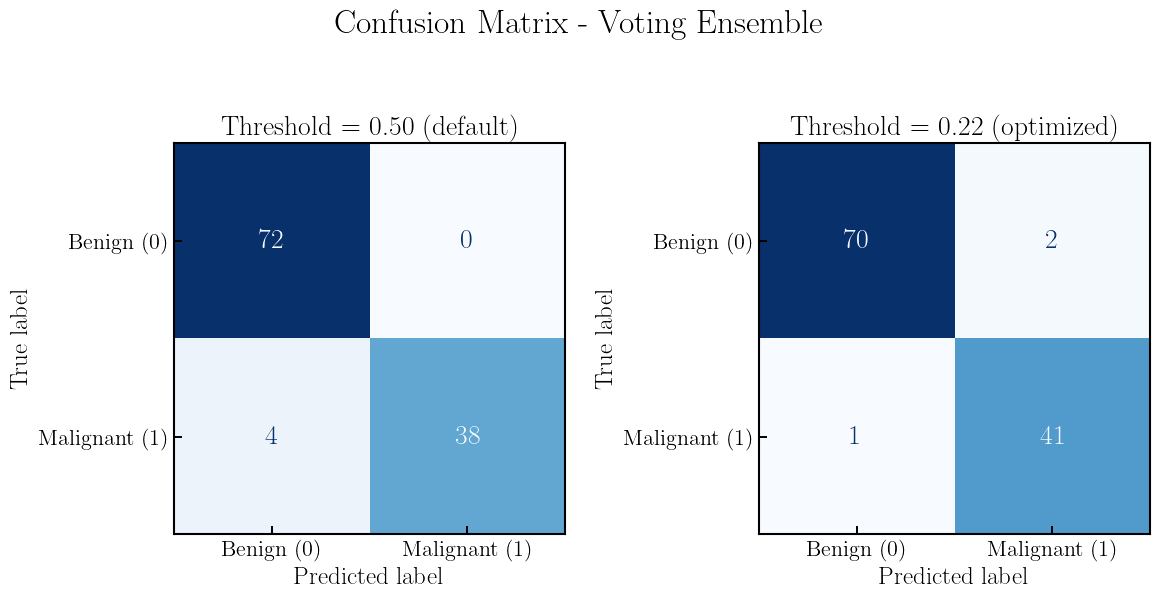

In [25]:
# Confusion matrix for the voting ensemble on the untouched test split.
# We compare the default threshold with the optimized one. 
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Default threshold (0.5)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_voting_default,
    display_labels=["Benign (0)", "Malignant (1)"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title(f"Threshold = 0.50 (default)")

# Optimized threshold
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_voting,
    display_labels=["Benign (0)", "Malignant (1)"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(f"Threshold = {thresholds['Voting']:.2f} (optimized)")

# Add common title
fig.suptitle("Confusion Matrix - Voting Ensemble", fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("figs/confusion_matrix_voting_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

## Feature importance analysis

In [26]:
# We do a final fit of all tuned models
for model in tuned_models.values():
    model.fit(X_train, y_train)

In [27]:
importances = {}

for name, model in tuned_models.items():

    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    importances[name] = {
        "mean": result.importances_mean,
        "std": result.importances_std
    }

importance_df = pd.DataFrame(
    {
        model: values["mean"]
        for model, values in importances.items()
    },
    index=X.columns
)

importance_std_df = pd.DataFrame(
    {
        model: values["std"]
        for model, values in importances.items()
    },
    index=X.columns
)

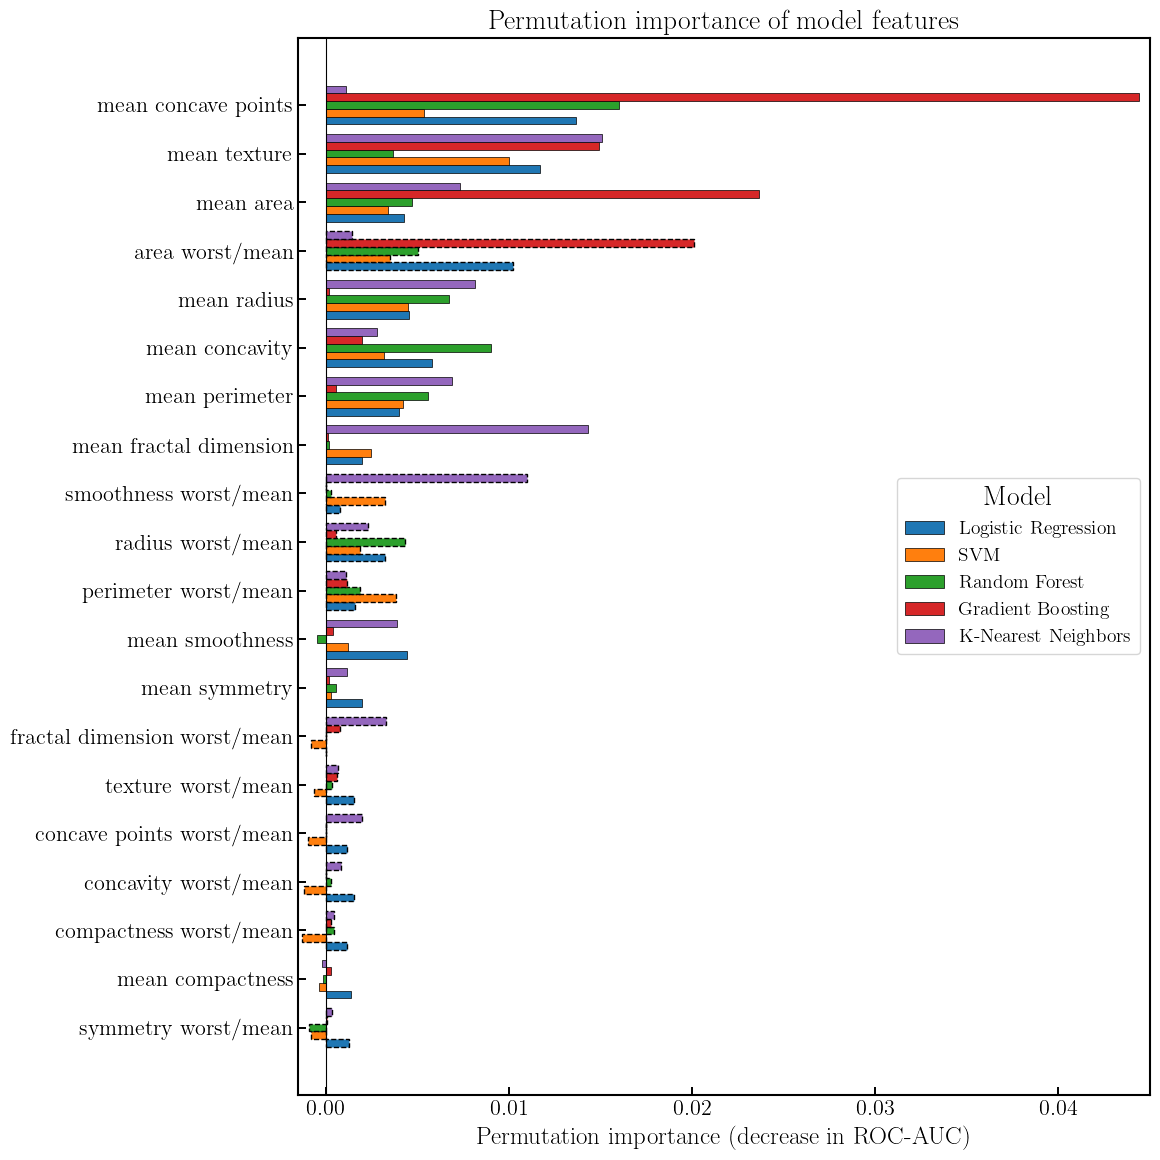

In [28]:
features = mean_features + ratio_features

# Sort features by the average importance across all models
mean_importance = importance_df.mean(axis=1).sort_values()
features = mean_importance.index

fig, ax = plt.subplots(figsize=(12, 12))

n_models = len(importance_df.columns)
n_features = len(features)

bar_height = 0.16
offsets = np.linspace(
    -(n_models - 1) * bar_height / 2,
    (n_models - 1) * bar_height / 2,
    n_models
)

# I removed the errorbars in the plot because it gets too crowded
for i, model in enumerate(importance_df.columns):

    values = importance_df.loc[features, model]
    errors = importance_std_df.loc[features, model]

    is_ratio = np.array(["worst/mean" in feature for feature in features])

    # Means: solid edge
    ax.barh(
        np.arange(n_features)[~is_ratio] + offsets[i],
        values[~is_ratio],
        height=bar_height,
        #xerr=errors[~is_ratio],
        label=model,
        color=f"C{i}",
        capsize=2,
        edgecolor="black",
        linewidth=0.5
    )

    # Ratios: dashed edge
    ax.barh(
        np.arange(n_features)[is_ratio] + offsets[i],
        values[is_ratio],
        height=bar_height,
        #xerr=errors[is_ratio],
        color=f"C{i}",
        capsize=2,
        edgecolor="black",
        linewidth=1.0,
        linestyle="--"
    )

ax.set_yticks(np.arange(n_features))
ax.set_yticklabels(features)

ax.set_xlabel("Permutation importance (decrease in ROC-AUC)")
ax.set_title("Permutation importance of model features")

ax.legend(title="Model", loc="center right")

ax.axvline(0, color="black", linewidth=0.8)
plt.xlim(-0.0015, 0.045)
plt.tight_layout()
plt.savefig("figs/feature_importance.png", dpi=200)
plt.show()